# Projeto Final — Processamento e Visualização de Dados com Python

## Classificação dos investimentos em IA e adoção corporativa de IA

**Integrantes:** Alanna Chaves, Carla Nascimento e Cristina Camacho  
**Fonte principal:** *AI Index Report 2026*, Stanford Institute for Human-Centered Artificial Intelligence (HAI)


## Resumo executivo

- Entre 2013 e 2024, os investimentos corporativos globais em IA somaram **US$ 1.619,34 bilhões** nas quatro classificações disponíveis.
- **Investimento privado** foi a maior categoria, com **US$ 760,23 bilhões (46,95%)**, seguido por **fusões e aquisições**, com **US$ 628,54 bilhões (38,81%)**.
- No período comum de 2017 a 2024, o investimento corporativo total cresceu **371,0%**, o investimento privado cresceu **489,0%** e a adoção corporativa de IA avançou de **20% para 78%**.
- A correlação de Pearson foi **0,56** entre investimento total e adoção e **0,76** entre investimento privado e adoção. Os valores indicam associação positiva, mas não comprovam causalidade.


## 1. Origem e contexto dos dados

O *AI Index Report 2026* é publicado pelo Stanford HAI e consolida dados de fontes especializadas. Este trabalho utiliza dois arquivos públicos do capítulo **4 — Economy**:

| Arquivo | Conteúdo original | Recorte analisado |
|---|---|---|
| `fig_4.2.1.csv` | Investimento corporativo em IA por tipo | 2013–2024 |
| `fig_4.3.1(1).csv` | Adoção organizacional de IA e IA generativa | IA em 2017–2024 |

Os dados de investimento têm como fonte a **Quid (2025)**. Os dados de adoção vêm da **McKinsey & Company Survey (2025)**. São bases secundárias, globais e produzidas por metodologias diferentes.


## 2. Pergunta de pesquisa

> **Em que medida o volume de investimentos em inteligência artificial é classificado e está associado ao ritmo de adoção de IA no período de 2013 a 2024?**

### Delimitação necessária

A pergunta será respondida em duas etapas:

1. Classificar e comparar o volume de investimentos em IA entre 2013 e 2024.
2. Medir a associação entre investimento e adoção de IA no período em que ambos estão disponíveis, **2017–2024**.

A base não contém adoção geral de IA entre 2013 e 2016. Por isso, a classificação usa todo o período de 2013–2024, enquanto a correlação usa os oito anos comuns de 2017–2024. A correlação é interpretada como associação descritiva, sem afirmação causal.


## 3. Estratégia de análise

1. Carregar as duas bases e aplicar o limite de 2024 definido na pergunta.
2. Verificar estrutura, valores ausentes, duplicidades, cobertura temporal e escalas.
3. Padronizar nomes, percentuais e categorias.
4. Classificar o investimento por tipo e comparar volume acumulado, participação e evolução anual.
5. Identificar valores extremos pelo intervalo interquartil e decidir seu tratamento.
6. Comparar a evolução do investimento e da adoção de IA entre 2017 e 2024 e calcular a correlação de Pearson.
7. Demonstrar a transformação da variável categórica com *one-hot encoding*.


## 4. Preparação do ambiente e leitura dos dados


In [1]:
%matplotlib inline
import sys

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.2f}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

PASTA_DADOS = "AI_INDEX_REPORT_2026/4. Economy/Data"

investimento_original = pd.read_csv(f"{PASTA_DADOS}/fig_4.2.1.csv")
adocao_original = pd.read_csv(f"{PASTA_DADOS}/fig_4.3.1(1).csv")

investimento = investimento_original[investimento_original["Year"].between(2013, 2024)].copy()
adocao_ia = adocao_original[
    (adocao_original["Label"] == "AI")
    & (adocao_original["Year"].between(2013, 2024))
].copy()

print("Bases carregadas e limitadas ao período da pergunta.")


Bases carregadas e limitadas ao período da pergunta.


In [2]:
estrutura = pd.DataFrame({
    "Base analisada": ["Investimentos", "Adoção de IA"],
    "Linhas": [len(investimento), len(adocao_ia)],
    "Colunas": [investimento.shape[1], adocao_ia.shape[1]],
    "Ano inicial observado": [investimento["Year"].min(), adocao_ia["Year"].min()],
    "Ano final observado": [investimento["Year"].max(), adocao_ia["Year"].max()],
})

display(estrutura)
display(investimento.head())
display(adocao_ia)


,Base analisada,Linhas,Colunas,Ano inicial observado,Ano final observado
0,Investimentos,48,3,2013,2024
1,Adoção de IA,8,3,2017,2024


,Year,Event Type,Funding in USD (billions)
0,2013,Merger/Acquisition,5.92
1,2013,Minority Stake,1.93
2,2013,Private Investment,5.17
3,2013,Public Offering,1.55
4,2014,Merger/Acquisition,6.69


,Year,% of respondents,Label
3,2017,0.20,AI
4,2018,0.47,AI
5,2019,0.58,AI
6,2020,0.50,AI
7,2021,0.56,AI
8,2022,0.50,AI
9,2023,0.55,AI
10,2024,0.78,AI


### Dicionário resumido

- `Year`: ano da observação.
- `Event Type`: classificação do investimento.
- `Funding in USD (billions)`: investimento em bilhões de dólares correntes.
- `% of respondents`: proporção de respondentes, armazenada entre 0 e 1.
- `Label`: tecnologia pesquisada; neste trabalho foi selecionada `AI`, que representa IA em geral.


## 5. Qualidade dos dados e transformações


In [3]:
qualidade = pd.DataFrame({
    "Base": ["Investimentos", "Adoção de IA"],
    "Valores ausentes": [
        int(investimento.isna().sum().sum()),
        int(adocao_ia.isna().sum().sum()),
    ],
    "Linhas duplicadas": [
        int(investimento.duplicated().sum()),
        int(adocao_ia.duplicated().sum()),
    ],
    "Chaves duplicadas": [
        int(investimento.duplicated(subset=["Year", "Event Type"]).sum()),
        int(adocao_ia.duplicated(subset=["Year", "Label"]).sum()),
    ],
})

anos_esperados = set(range(2013, 2025))
anos_investimento = set(investimento["Year"])
anos_adocao = set(adocao_ia["Year"])

display(qualidade)
print("Anos sem dados de investimento:", sorted(anos_esperados - anos_investimento))
print("Anos sem medição de adoção de IA:", sorted(anos_esperados - anos_adocao))


,Base,Valores ausentes,Linhas duplicadas,Chaves duplicadas
0,Investimentos,0,0,0
1,Adoção de IA,0,0,0


Anos sem dados de investimento: []
Anos sem medição de adoção de IA: [2013, 2014, 2015, 2016]


### Diagnóstico

- Não foram encontrados valores ausentes, linhas repetidas ou chaves duplicadas.
- A grade de investimentos está completa: quatro classificações em cada ano de 2013 a 2024, totalizando 48 linhas.
- A ausência de adoção de IA em 2013–2016 não aparece como `NaN`; são anos que não foram medidos nessa série. Eles não podem ser preenchidos com zero, pois zero significaria adoção observada igual a 0%.
- A adoção está armazenada como proporção entre 0 e 1 e será convertida para percentual.


In [4]:
investimento = investimento.rename(columns={
    "Year": "Ano",
    "Event Type": "Tipo de investimento",
    "Funding in USD (billions)": "Investimento (US$ bi)",
})
adocao_ia = adocao_ia.rename(columns={
    "Year": "Ano",
    "% of respondents": "Proporção de respondentes",
    "Label": "Tecnologia",
})

traducao_tipos = {
    "Merger/Acquisition": "Fusões e aquisições",
    "Minority Stake": "Participação minoritária",
    "Private Investment": "Investimento privado",
    "Public Offering": "Oferta pública",
}
investimento["Tipo de investimento"] = (
    investimento["Tipo de investimento"]
    .replace(traducao_tipos)
    .astype("category")
)
adocao_ia["Adoção de IA (%)"] = adocao_ia["Proporção de respondentes"] * 100

print("Tipos após a padronização:")
display(investimento.dtypes.to_frame("dtype"))


Tipos após a padronização:


,dtype
Ano,int64
Tipo de investimento,category
Investimento (US$ bi),float64


## 6. Classificação do volume de investimentos


In [5]:
resumo_investimento = (
    investimento.groupby("Tipo de investimento", observed=True)["Investimento (US$ bi)"]
    .agg(["count", "sum", "mean", "min", "max"])
    .rename(columns={"count": "n", "sum": "Soma", "mean": "Média", "min": "Mínimo", "max": "Máximo"})
)
resumo_investimento["Participação no total (%)"] = (
    resumo_investimento["Soma"] / resumo_investimento["Soma"].sum() * 100
)
resumo_investimento = resumo_investimento.sort_values("Soma", ascending=False).round(2)

display(resumo_investimento)
print(f"Volume acumulado nas quatro categorias: US$ {resumo_investimento['Soma'].sum():,.2f} bilhões")


,n,Soma,Média,Mínimo,Máximo,Participação no total (%)
Tipo de investimento,,,,,,
Investimento privado,12,760.23,63.35,5.17,151.48,46.95
Fusões e aquisições,12,628.54,52.38,5.92,175.36,38.81
Participação minoritária,12,123.70,10.31,0.34,88.19,7.64
Oferta pública,12,106.87,8.91,1.55,37.32,6.60


Volume acumulado nas quatro categorias: US$ 1,619.34 bilhões


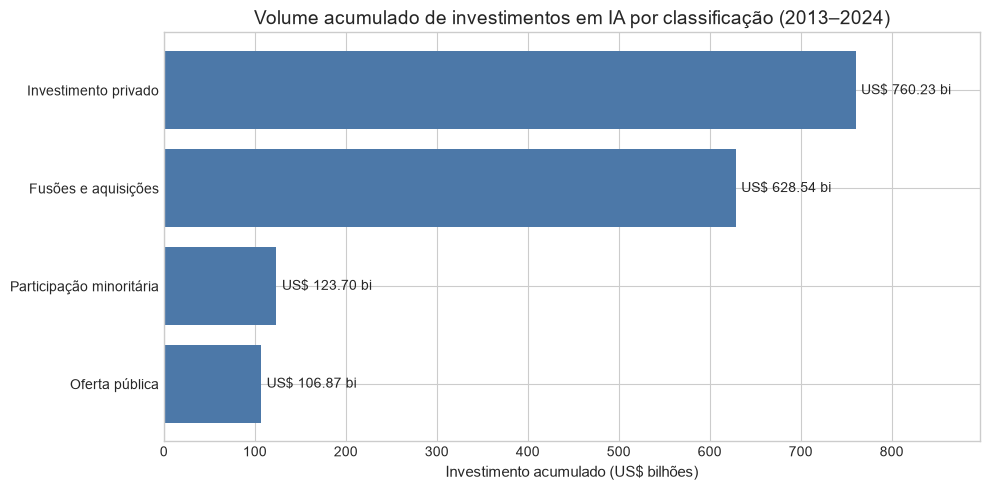

In [6]:
classificacao_plot = resumo_investimento.sort_values("Soma")

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(
    classificacao_plot.index,
    classificacao_plot["Soma"],
    color="#4c78a8",
)
ax.set_title("Volume acumulado de investimentos em IA por classificação (2013–2024)")
ax.set_xlabel("Investimento acumulado (US$ bilhões)")
ax.set_ylabel("")
ax.bar_label(barras, fmt="US$ %.2f bi", padding=4)
ax.set_xlim(0, classificacao_plot["Soma"].max() * 1.18)
plt.tight_layout()
plt.show()


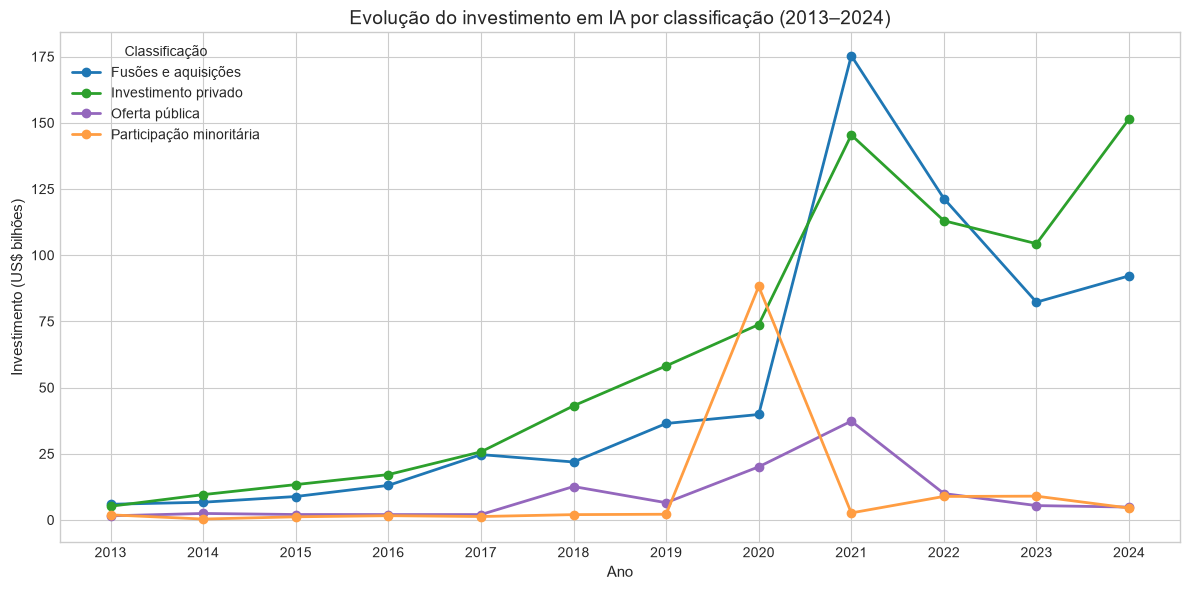

In [7]:
cores_tipos = {
    "Fusões e aquisições": "#1f77b4",
    "Participação minoritária": "#ff9d42",
    "Investimento privado": "#2ca02c",
    "Oferta pública": "#9467bd",
}

fig, ax = plt.subplots(figsize=(12, 6))
for tipo, grupo in investimento.groupby("Tipo de investimento", observed=True):
    ax.plot(
        grupo["Ano"],
        grupo["Investimento (US$ bi)"],
        marker="o",
        linewidth=2,
        label=tipo,
        color=cores_tipos[tipo],
    )

ax.set_title("Evolução do investimento em IA por classificação (2013–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("Investimento (US$ bilhões)")
ax.set_xticks(sorted(investimento["Ano"].unique()))
ax.legend(title="Classificação")
plt.tight_layout()
plt.show()


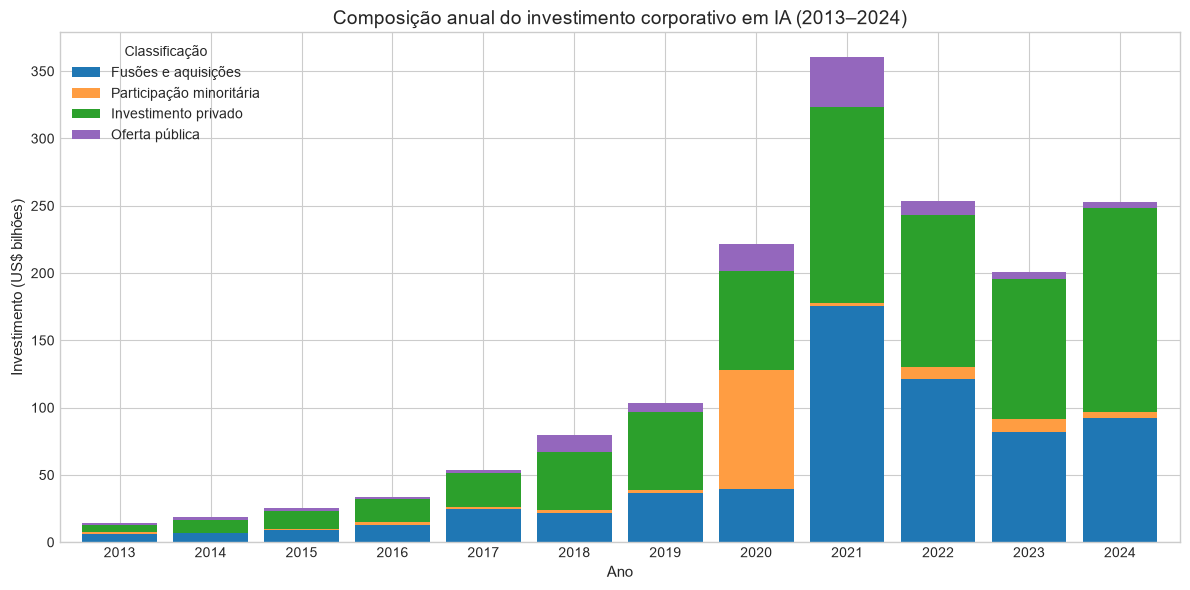

In [8]:
composicao_anual = investimento.pivot(
    index="Ano",
    columns="Tipo de investimento",
    values="Investimento (US$ bi)",
)
ordem_colunas = list(cores_tipos.keys())
composicao_anual = composicao_anual[ordem_colunas]

ax = composicao_anual.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[cores_tipos[tipo] for tipo in ordem_colunas],
    width=0.82,
)
ax.set_title("Composição anual do investimento corporativo em IA (2013–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("Investimento (US$ bilhões)")
ax.legend(title="Classificação", loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


O investimento privado representa 46,95% do volume acumulado e fusões e aquisições representam 38,81%. Juntas, as duas categorias concentram 85,76% do total de 2013–2024. A composição varia por ano: por exemplo, a participação minoritária apresenta um pico isolado em 2020, enquanto investimento privado e fusões e aquisições lideram a maior parte do período recente.


## 7. Valores extremos e decisão de tratamento


,Classificação,Limite inferior,Limite superior
0,Fusões e aquisições,-97.11,193.86
1,Investimento privado,-119.30,241.99
2,Oferta pública,-10.84,23.51
3,Participação minoritária,-4.56,11.67


,Classificação,Ano,Investimento (US$ bi)
0,Oferta pública,2021,37.32
1,Participação minoritária,2020,88.19


Limites IQR da adoção: 38.38% a 67.38%


,Adoção de IA (%)
Ano,
2017,20.00
2024,78.00


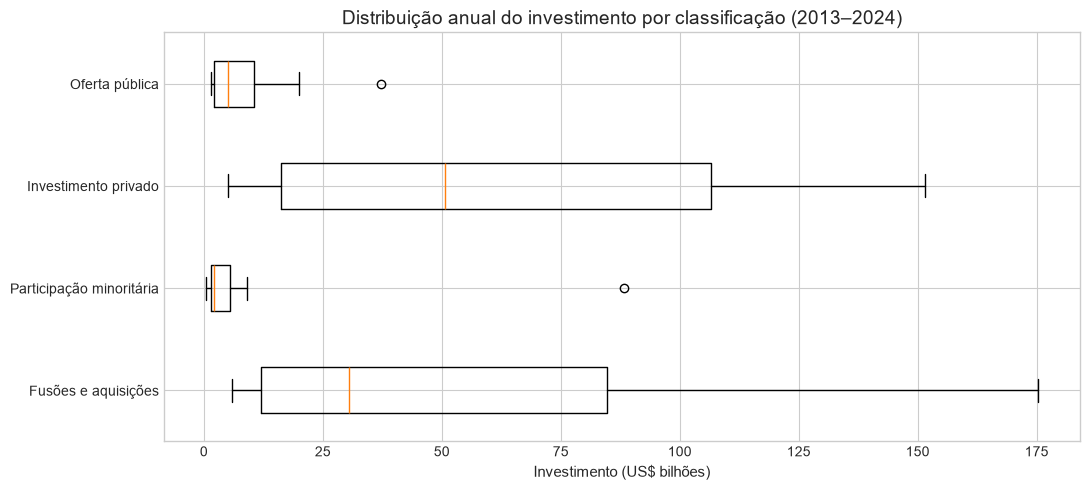

In [9]:
limites_iqr = []
valores_extremos = []

for tipo, grupo in investimento.groupby("Tipo de investimento", observed=True):
    serie = grupo.set_index("Ano")["Investimento (US$ bi)"]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    limites_iqr.append({
        "Classificação": tipo,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior,
    })
    for ano, valor in serie[(serie < limite_inferior) | (serie > limite_superior)].items():
        valores_extremos.append({
            "Classificação": tipo,
            "Ano": ano,
            "Investimento (US$ bi)": valor,
        })

display(pd.DataFrame(limites_iqr).round(2))
display(pd.DataFrame(valores_extremos).round(2))

serie_adocao = adocao_ia.set_index("Ano")["Adoção de IA (%)"]
q1_adocao = serie_adocao.quantile(0.25)
q3_adocao = serie_adocao.quantile(0.75)
iqr_adocao = q3_adocao - q1_adocao
limite_inferior_adocao = q1_adocao - 1.5 * iqr_adocao
limite_superior_adocao = q3_adocao + 1.5 * iqr_adocao
extremos_adocao = serie_adocao[
    (serie_adocao < limite_inferior_adocao)
    | (serie_adocao > limite_superior_adocao)
]

print(
    f"Limites IQR da adoção: {limite_inferior_adocao:.2f}% a "
    f"{limite_superior_adocao:.2f}%"
)
display(extremos_adocao.rename("Adoção de IA (%)").to_frame())

tipos = list(cores_tipos.keys())
dados_boxplot = [
    investimento.loc[investimento["Tipo de investimento"] == tipo, "Investimento (US$ bi)"]
    for tipo in tipos
]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(dados_boxplot, tick_labels=tipos, orientation="horizontal")
ax.set_title("Distribuição anual do investimento por classificação (2013–2024)")
ax.set_xlabel("Investimento (US$ bilhões)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


O IQR sinaliza o valor de participação minoritária em 2020, o de oferta pública em 2021 e os extremos de adoção em 2017 e 2024. Eles são mantidos porque coincidem com registros válidos das fontes e ajudam a representar a evolução observada. A identificação pelo IQR é um alerta de distribuição, não uma prova de erro.


## 8. Ritmo de adoção corporativa de IA


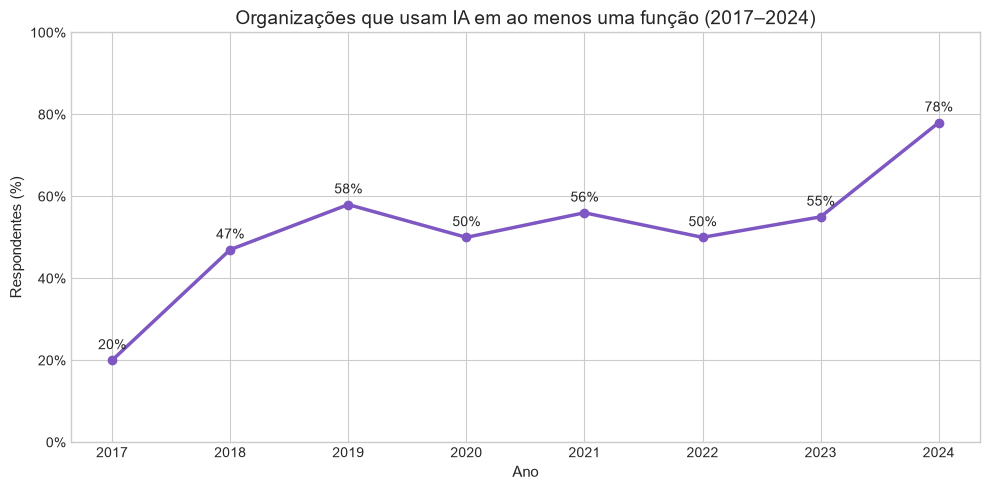

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    adocao_ia["Ano"],
    adocao_ia["Adoção de IA (%)"],
    marker="o",
    linewidth=2.5,
    color="#7e57c2",
)
for _, linha in adocao_ia.iterrows():
    ax.annotate(
        f"{linha['Adoção de IA (%)']:.0f}%",
        (linha["Ano"], linha["Adoção de IA (%)"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )
ax.set_title("Organizações que usam IA em ao menos uma função (2017–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("Respondentes (%)")
ax.set_xticks(adocao_ia["Ano"])
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(100))
plt.tight_layout()
plt.show()


A proporção de respondentes que informou uso de IA em ao menos uma função organizacional passou de 20% em 2017 para 78% em 2024. A série não cresce de forma contínua: há recuos em 2020 e 2022, seguidos por avanço mais intenso em 2024.


## 9. Associação no período comum: 2017–2024


In [11]:
investimento_total_anual = (
    investimento.groupby("Ano")["Investimento (US$ bi)"].sum().rename("Investimento total (US$ bi)")
)
investimento_privado_anual = (
    investimento[investimento["Tipo de investimento"] == "Investimento privado"]
    .set_index("Ano")["Investimento (US$ bi)"]
    .rename("Investimento privado (US$ bi)")
)

comparacao = (
    adocao_ia[["Ano", "Adoção de IA (%)"]]
    .merge(investimento_total_anual, on="Ano", how="inner")
    .merge(investimento_privado_anual, on="Ano", how="inner")
    .sort_values("Ano")
)

correlacao_total = comparacao["Investimento total (US$ bi)"].corr(
    comparacao["Adoção de IA (%)"]
)
correlacao_privado = comparacao["Investimento privado (US$ bi)"].corr(
    comparacao["Adoção de IA (%)"]
)

variacoes = pd.Series({
    "Investimento total (%)": (
        comparacao.iloc[-1]["Investimento total (US$ bi)"]
        / comparacao.iloc[0]["Investimento total (US$ bi)"] - 1
    ) * 100,
    "Investimento privado (%)": (
        comparacao.iloc[-1]["Investimento privado (US$ bi)"]
        / comparacao.iloc[0]["Investimento privado (US$ bi)"] - 1
    ) * 100,
    "Adoção de IA — variação relativa (%)": (
        comparacao.iloc[-1]["Adoção de IA (%)"]
        / comparacao.iloc[0]["Adoção de IA (%)"] - 1
    ) * 100,
})

display(comparacao)
display(variacoes.round(1).to_frame("Variação de 2017 para 2024"))
print("Adoção de IA: +58 pontos percentuais")
print(f"Correlação — investimento total × adoção: {correlacao_total:.2f}")
print(f"Correlação — investimento privado × adoção: {correlacao_privado:.2f}")


,Ano,Adoção de IA (%),Investimento total (US$ bi),Investimento privado (US$ bi)
0,2017,20.00,53.72,25.72
1,2018,47.00,79.62,43.10
2,2019,58.00,103.27,58.18
3,2020,50.00,221.87,73.79
4,2021,56.00,360.73,145.40
5,2022,50.00,253.25,113.01
6,2023,55.00,201.00,104.34
7,2024,78.00,253.02,151.48


,Variação de 2017 para 2024
Investimento total (%),371.00
Investimento privado (%),489.00
Adoção de IA — variação relativa (%),290.00


Adoção de IA: +58 pontos percentuais
Correlação — investimento total × adoção: 0.56
Correlação — investimento privado × adoção: 0.76


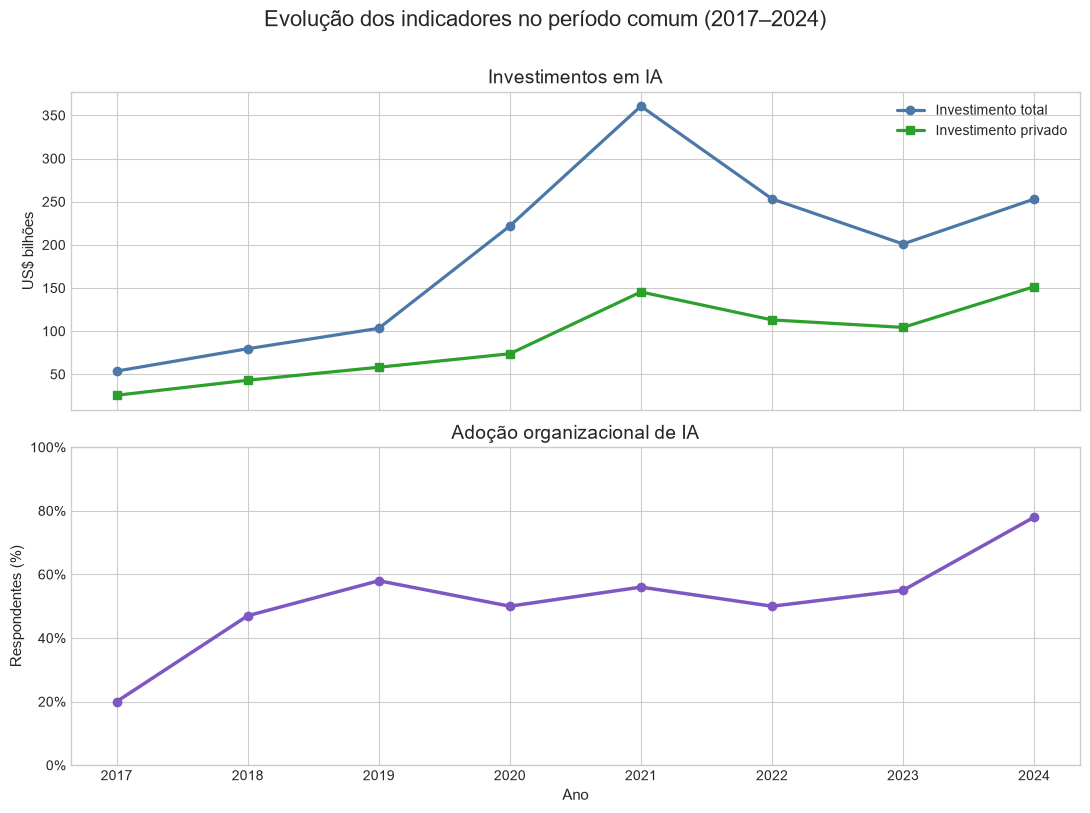

In [12]:
fig, eixos = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

eixos[0].plot(
    comparacao["Ano"], comparacao["Investimento total (US$ bi)"],
    marker="o", linewidth=2.3, color="#4c78a8", label="Investimento total"
)
eixos[0].plot(
    comparacao["Ano"], comparacao["Investimento privado (US$ bi)"],
    marker="s", linewidth=2.3, color="#2ca02c", label="Investimento privado"
)
eixos[0].set_title("Investimentos em IA")
eixos[0].set_ylabel("US$ bilhões")
eixos[0].legend()

eixos[1].plot(
    comparacao["Ano"], comparacao["Adoção de IA (%)"],
    marker="o", linewidth=2.5, color="#7e57c2"
)
eixos[1].set_title("Adoção organizacional de IA")
eixos[1].set_xlabel("Ano")
eixos[1].set_ylabel("Respondentes (%)")
eixos[1].set_ylim(0, 100)
eixos[1].set_xticks(comparacao["Ano"])
eixos[1].yaxis.set_major_formatter(PercentFormatter(100))

fig.suptitle("Evolução dos indicadores no período comum (2017–2024)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


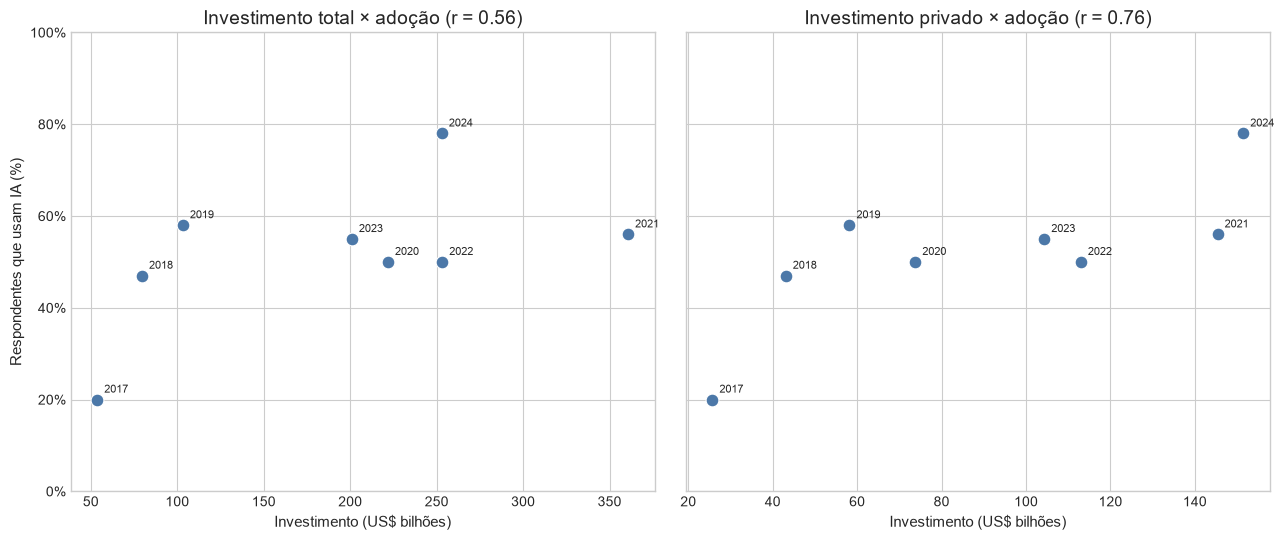

In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

pares = [
    ("Investimento total (US$ bi)", correlacao_total, "Investimento total"),
    ("Investimento privado (US$ bi)", correlacao_privado, "Investimento privado"),
]

for eixo, (coluna, correlacao, titulo) in zip(eixos, pares):
    eixo.scatter(
        comparacao[coluna], comparacao["Adoção de IA (%)"],
        s=85, color="#4c78a8", edgecolor="white", linewidth=0.8
    )
    for _, linha in comparacao.iterrows():
        eixo.annotate(
            str(int(linha["Ano"])),
            (linha[coluna], linha["Adoção de IA (%)"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )
    eixo.set_title(f"{titulo} × adoção (r = {correlacao:.2f})")
    eixo.set_xlabel("Investimento (US$ bilhões)")
    eixo.set_ylim(0, 100)
    eixo.yaxis.set_major_formatter(PercentFormatter(100))

eixos[0].set_ylabel("Respondentes que usam IA (%)")
plt.tight_layout()
plt.show()


### Interpretação da associação

No período comum, a associação entre investimento total e adoção foi positiva (**r = 0,56**). Para o investimento privado, a associação foi maior (**r = 0,76**). Isso significa que anos com maior investimento tendem a coincidir com maior adoção, especialmente na categoria privada. Entretanto, as séries compartilham uma tendência de crescimento, contêm apenas oito observações e vêm de fontes diferentes. Portanto, os resultados não permitem concluir que o investimento causou o aumento da adoção.


## 10. Codificação da variável categórica


In [14]:
from sklearn.preprocessing import OneHotEncoder

codificador = OneHotEncoder(sparse_output=False, dtype=int)
matriz_codificada = codificador.fit_transform(investimento[["Tipo de investimento"]])
colunas_codificadas = codificador.get_feature_names_out(["Tipo de investimento"])

tipos_codificados = pd.DataFrame(
    matriz_codificada,
    columns=colunas_codificadas,
    index=investimento.index,
)
base_numerica = pd.concat(
    [investimento[["Ano", "Investimento (US$ bi)"]], tipos_codificados],
    axis=1,
)

print(f"Base original: {investimento.shape[1]} colunas")
print(f"Base preparada para modelagem: {base_numerica.shape[1]} colunas")
display(base_numerica.head(8))


Base original: 3 colunas
Base preparada para modelagem: 6 colunas


,Ano,Investimento (US$ bi),Tipo de investimento_Fusões e aquisições,Tipo de investimento_Investimento privado,Tipo de investimento_Oferta pública,Tipo de investimento_Participação minoritária
0,2013,5.92,1,0,0,0
1,2013,1.93,0,0,0,1
2,2013,5.17,0,1,0,0
3,2013,1.55,0,0,1,0
4,2014,6.69,1,0,0,0
5,2014,0.34,0,0,0,1
6,2014,9.56,0,1,0,0
7,2014,2.45,0,0,1,0


O *one-hot encoding* transforma cada classificação de investimento em uma coluna binária, sem criar uma ordem artificial entre as categorias. A transformação é demonstrada para atender à etapa de tratamento de variáveis categóricas; os gráficos descritivos continuam usando os rótulos originais por serem mais interpretáveis.


## 11. Conclusões

1. **Classificação:** entre 2013 e 2024, o investimento corporativo em IA totalizou US$ 1.619,34 bilhões. Investimento privado respondeu por 46,95% e fusões e aquisições por 38,81%.
2. **Concentração:** as duas maiores categorias reuniram 85,76% do volume acumulado.
3. **Período comum:** entre 2017 e 2024, o investimento total cresceu 371,0%, o investimento privado cresceu 489,0% e a adoção de IA passou de 20% para 78%.
4. **Associação:** a correlação foi positiva tanto para o investimento total (r = 0,56) quanto para o investimento privado (r = 0,76), que apresentou a associação mais elevada.

Assim, os dados permitem classificar os investimentos em todo o período solicitado e medir uma associação positiva com a adoção de IA nos oito anos comuns. A associação não deve ser interpretada como causalidade.


## 12. Limitações

- A adoção corporativa de IA está disponível somente a partir de 2017, enquanto o investimento começa em 2013.
- A correlação utiliza apenas oito observações anuais e pode ser influenciada pela tendência temporal das séries.
- Investimento e adoção vêm de fontes e metodologias diferentes.
- Os valores de investimento são globais e não podem ser ligados às organizações respondentes da pesquisa.
- Os valores monetários são apresentados em dólares correntes, sem ajuste pela inflação.
- Crescimento simultâneo não estabelece causalidade nem descarta fatores como infraestrutura, disponibilidade de produtos, qualificação e regulamentação.


## 13. Possíveis aplicações futuras

- Atualizar a análise quando houver mais anos de adoção corporativa de IA.
- Manter definições geográficas comparáveis entre investimento e adoção.
- Ajustar os valores monetários pela inflação.
- Incorporar investimento e adoção por país, região ou setor quando existirem séries comparáveis.
- Com um histórico maior, testar defasagens temporais e modelos que controlem a tendência de crescimento.


## 14. Referências, reprodutibilidade e uso de IA generativa

### Referências

- Stanford Institute for Human-Centered Artificial Intelligence. *AI Index Report 2026*, capítulo 4 — Economy.
- Quid (2025), fonte dos dados de investimento reproduzidos no relatório.
- McKinsey & Company Survey (2025), fonte dos dados de adoção reproduzidos no relatório.
- Arquivos públicos locais: `AI_INDEX_REPORT_2026/4. Economy/Data/`.

### Reprodutibilidade

O notebook usa caminhos relativos ao projeto e pode ser executado de cima para baixo. A célula abaixo registra as versões principais do ambiente utilizado.

### Declaração de uso de IA generativa

Foi utilizado **OpenAI Codex** como apoio na revisão da estrutura do notebook, simplificação do código, redação explicativa e validação de execução. A seleção dos dados, a interpretação dos resultados e a conferência final são de responsabilidade do grupo.


In [15]:
import sklearn

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")


Python: 3.13.14
pandas: 3.0.6
matplotlib: 3.11.2
scikit-learn: 1.9.1
